Libraries

In [20]:
import tensorflow as tf
import cv2
import os
from sklearn.model_selection import train_test_split
import numpy as np
from IPython.core import history

load dataset

In [4]:
(x_train,y_train),(x_test,y_test)=tf.keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


check dataset shapes

In [5]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


Image Size & Batch Size

In [6]:
image_size=(28,28)
Batch_size=32

Data Normalization

In [7]:
x_train=x_train.astype('float32')/255
x_test=x_test.astype('float32')/255


Print Number of Images

In [9]:
print(f"total train images:{len(x_train)}")
print(f"total test images:{len(x_test)}")

total train images:60000
total test images:10000


Build MLP Model

In [15]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),

    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(10, activation='softmax')
])

Model Summary

In [16]:
print("MLP model built successfully.")
model.summary()

MLP model built successfully.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

Compile

In [17]:
print("Compiling model...")
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

Compiling model...


Training

In [21]:

print("Training model....")
history=model.fit(
    x_train,y_train,
    epochs=10,
    batch_size=Batch_size,
    validation_data=(x_test,y_test)
)

Training model....
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.8809 - loss: 0.3252 - val_accuracy: 0.8709 - val_loss: 0.3556
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.8854 - loss: 0.3218 - val_accuracy: 0.8719 - val_loss: 0.3666
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.8845 - loss: 0.3181 - val_accuracy: 0.8826 - val_loss: 0.3354
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.8873 - loss: 0.3109 - val_accuracy: 0.8822 - val_loss: 0.3358
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.8853 - loss: 0.3145 - val_accuracy: 0.8775 - val_loss: 0.3309
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.8882 - loss: 0.3112 - val_accuracy: 0.8739 - val_loss: 0.3441
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.8883 - loss: 0.3056 - val_accuracy: 0.8844 - val_loss: 0.3318
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step -

Evaluation

In [22]:
print("Evaluating model..")
test_loss,test_accuracy=model.evaluate(
    x_test,y_test,
    batch_size=Batch_size,
    verbose=1
)
print(f"Test loss:{test_loss:.4f}")
print(f"Test accuracy:{test_accuracy:.4f}")


Evaluating model..
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8783 - loss: 0.3433
Test loss:0.3433
Test accuracy:0.8783


Prediction

In [23]:
y_pred=model.predict(x_test)
print(y_pred.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
(10000, 10)


Convert Predictions to Classes

In [24]:
y_pred_classes=np.argmax(y_pred,axis=1)
print(y_pred_classes.shape)

(10000,)


Class Names

In [25]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

Display Predictions

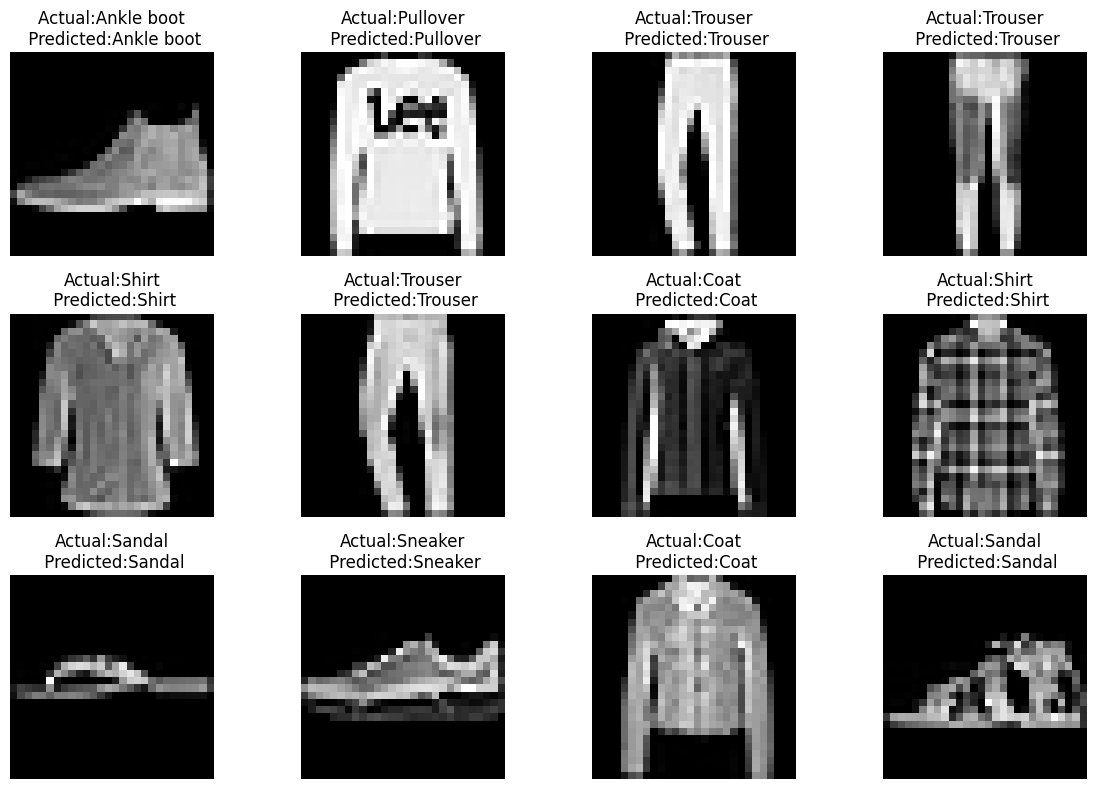

In [26]:
plt.figure(figsize=(12,8))
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(x_test[i],cmap="gray")

    actual=class_names[y_test[i]]
    predicted=class_names[y_pred_classes[i]]

    plt.title(f"Actual:{actual}\n Predicted:{predicted}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [38]:
model.save("mlp_model.keras")